
# Mouse contact network (empirical data)
=======================================

This example loads the mouse proximity-contact dataset published by
`König (2021) <https://doi.org/10.5281/zenodo.4725155>`_ and
analyses it as a continuous-time temporal network using
:class:`~tempnet.ContTempNetwork`.

The dataset records pairwise contact events (start time, end time, source
mouse, target mouse) collected over several days.  We restrict the analysis
to the **first hour** (3 600 s) to keep the example fast.

Two plots are produced:

1. **Contact timeline** — each contact is drawn as a horizontal bar; rows
   correspond to individual mice.
2. **Event-duration distribution** — histogram of contact durations.


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import time
from tqdm import tqdm
import seaborn as sns
import tempnet as tn
import os
from matplotlib.colors import LogNorm
import networkx as nx
from functools import reduce


In [3]:
datadir='Data'
os.makedirs(datadir, exist_ok=True)
!wget https://zenodo.org/record/4725155/files/mice_contact_sequence.csv.gz -P Data/

--2026-06-15 11:48:58--  https://zenodo.org/record/4725155/files/mice_contact_sequence.csv.gz
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.48.75, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4725155/files/mice_contact_sequence.csv.gz [following]
--2026-06-15 11:48:58--  https://zenodo.org/records/4725155/files/mice_contact_sequence.csv.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 53670209 (51M) [text/plain]
Saving to: 'Data/mice_contact_sequence.csv.gz'

     0K .......... .......... .......... .......... ..........  0%  790K 66s
    50K .......... .......... .......... .......... ..........  0% 3.37M 41s
   100K .......... .......... .......... .......... ..........  0% 4.61M 31s
   150K .......... .......... .......... .......... ..........  0% 3.59M 27s
   200K .......... .......

In [4]:
event_table=pd.read_csv('Data\mice_contact_sequence.csv.gz',compression='gzip')
event_table=event_table.round(2)

# filter 1 hour
event_table=event_table[event_table['starting_times']<=3600].reset_index(drop=True)

In [5]:
event_table.head()

,source_nodes,target_nodes,starting_times,ending_times,durations
0,61,67,11.13,37.85,26.73
1,270,276,12.68,137.17,124.49
2,256,269,12.82,64.95,52.13
3,256,398,20.90,49.94,29.04
4,269,398,20.90,49.94,29.04


In [6]:
tempo=tn.ContTempNetwork(events_table=event_table)

Now we find the number of nodes and number of events

In [7]:
print(tempo)

<class 'tempnet.temporal_network.ContTempNetwork'> with 257 nodes and 4310 events


so we have 257  mice, and roughly 4k events, makes it a nice dataset for understanding the temporal networks

In [9]:
print('Number of mice', tempo.num_nodes)
print('Number of events', tempo.num_events)

Number of mice 257
Number of events 4310


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


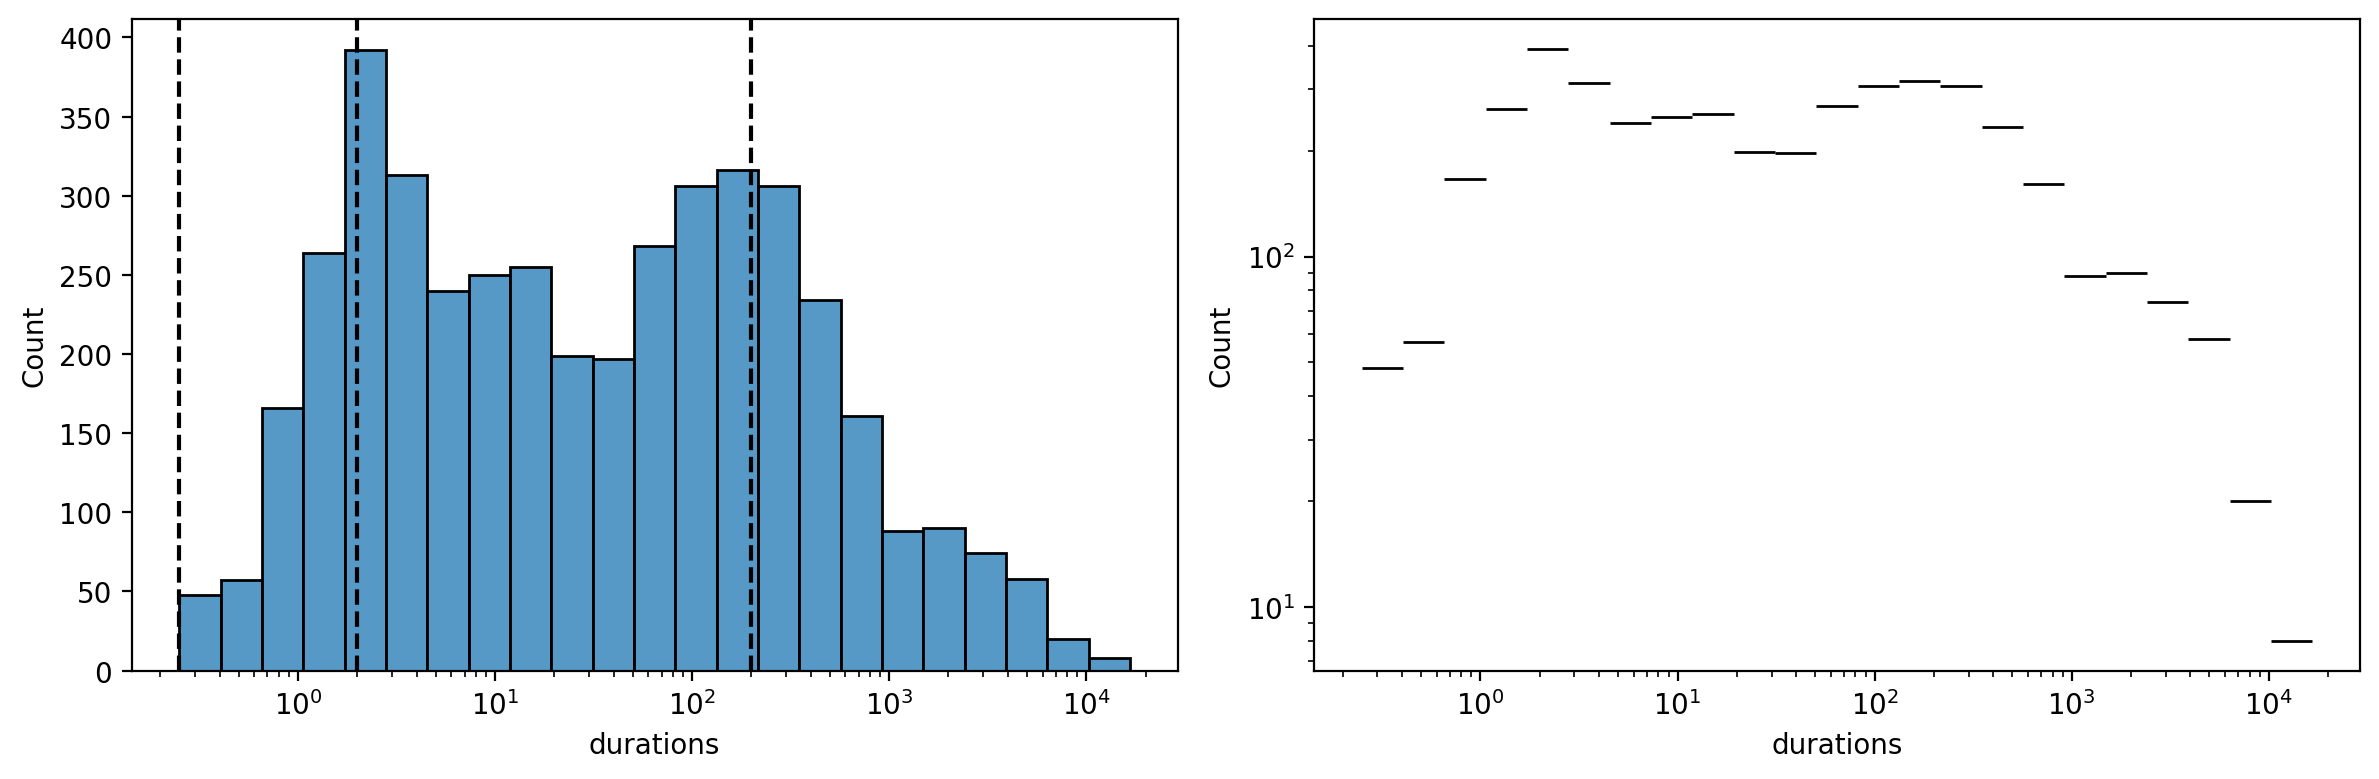

In [10]:
fig, ax=plt.subplots(nrows=1, ncols=2,figsize=(12, 4), dpi=200)
sns.histplot(data=tempo.events_table, x='durations', ax=ax[0], log_scale=(True, False))
sns.histplot(data=tempo.events_table, x='durations', ax=ax[1], log_scale=(True, True))
ax[0].axvline(0.25, color='k', linestyle='--')
ax[0].axvline(2, color='k', linestyle='--')
ax[0].axvline(200, color='k', linestyle='--')

plt.tight_layout()
plt.show()

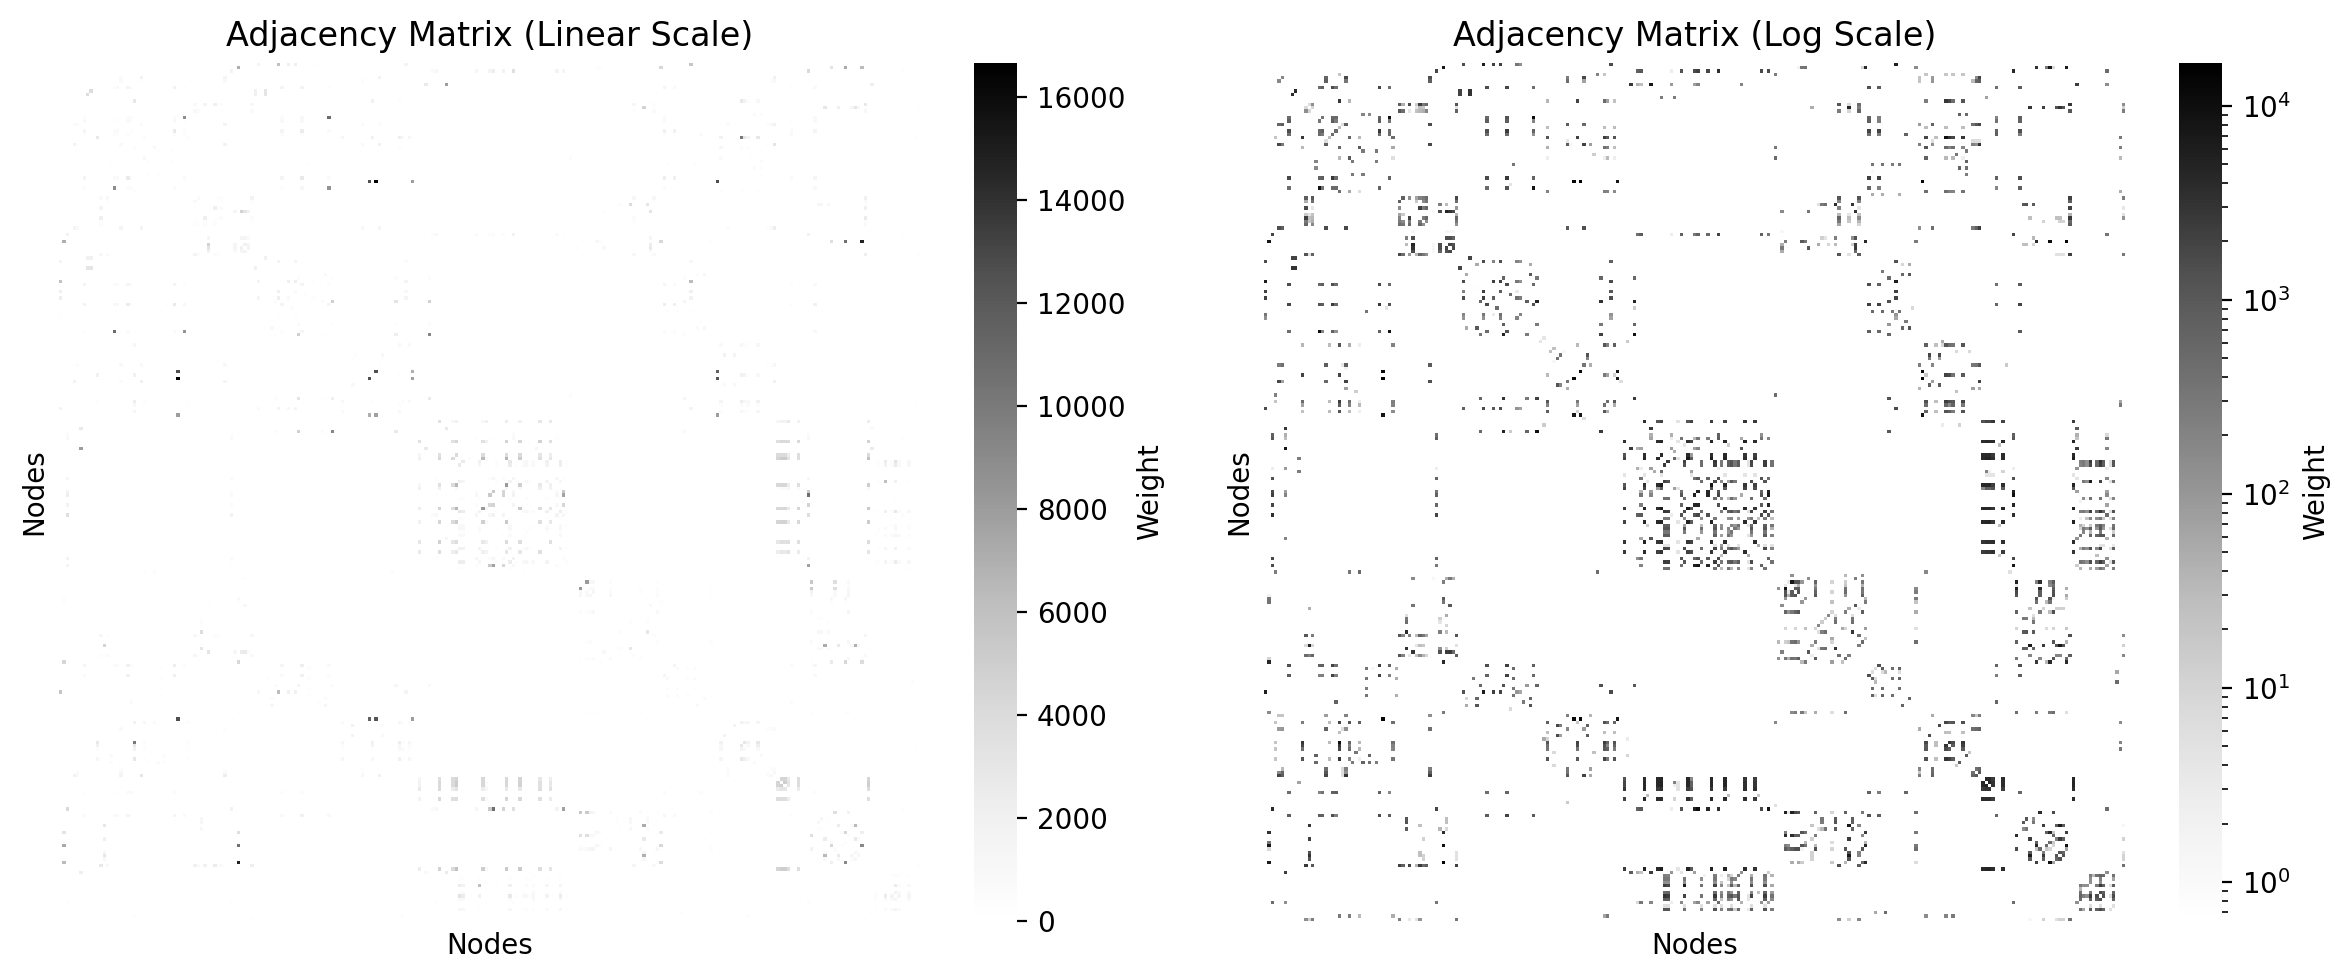

In [15]:
A = tempo.compute_static_adjacency_matrix()
A_dense = A.toarray()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, dpi=200, figsize=(12, 5))

sns.heatmap(A_dense, ax=ax1, cbar_kws={'label': 'Weight'}, cmap='Greys')
ax1.set_xlabel('Nodes')
ax1.set_ylabel('Nodes')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Adjacency Matrix (Linear Scale)')



A_log = A_dense.copy()
A_log[A_log == 0] = np.nan 

sns.heatmap(A_log, ax=ax2, norm=LogNorm(), cbar_kws={'label': 'Weight'}, cmap='Greys')
ax2.set_xlabel('Nodes')
ax2.set_ylabel('Nodes')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('Adjacency Matrix (Log Scale)')

plt.tight_layout()

We then transform it to a Networkx object to visualise and perform other algorithms and measure computation. 

In [16]:
static=nx.from_numpy_array(A.toarray())

In [17]:
nx.is_connected(static)

False

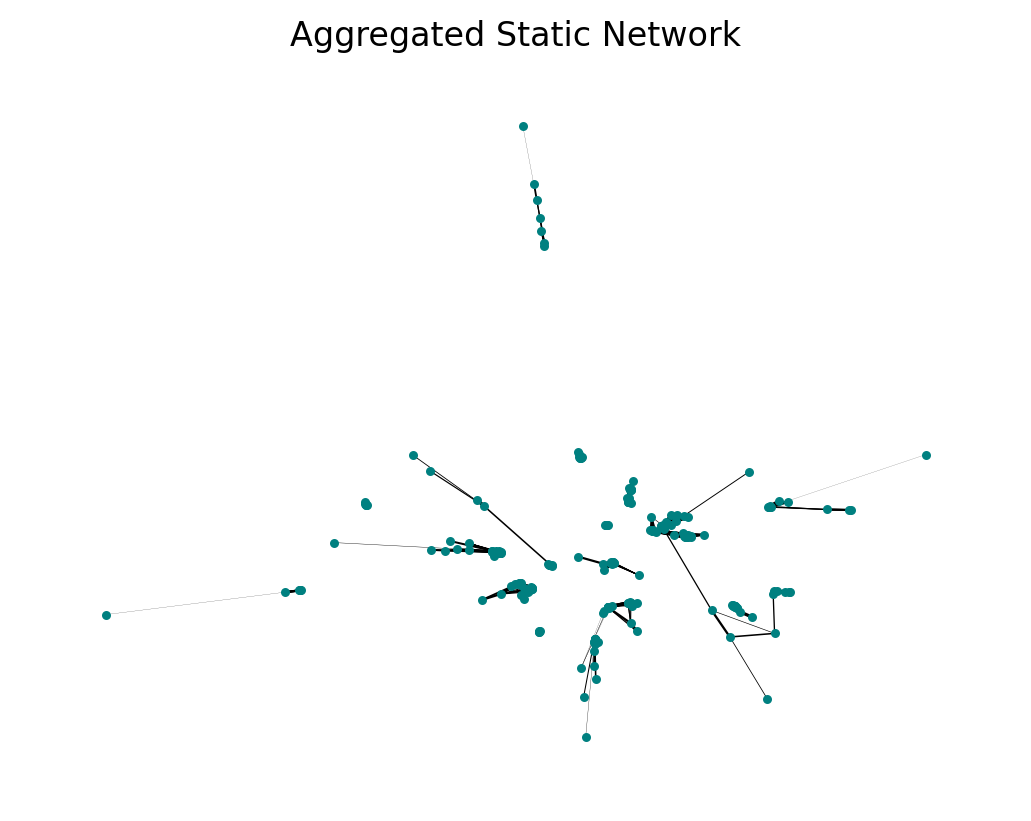

In [18]:
fig, ax=plt.subplots(nrows=1, ncols=1, dpi=200)

pos=nx.spring_layout(static, seed=412)
weights = [static[u][v]["weight"] for u, v in static.edges()]
max_w = max(weights)
widths = [ 2*np.log10(w) / np.log10(max_w) for w in weights] 

nx.draw(static, pos, with_labels=False, width=widths, node_color="teal", node_size=5)


plt.title("Aggregated Static Network")
plt.show()

The network is not connected, and it is clearly modular. 

To find the start and end of the temporal network, equivalently, the minimum start time and maximum end time, we can query the network directly:



In [19]:
print("Start:", tempo.start_time)
print("End:", tempo.end_time)

Start: 11.13
End: 17843.64


In [20]:
t=np.arange(0, 24*3600+1, 3600)
n_active=[tempo.num_active_nodes(t[i], t[i+1]) for i in range(len(t)-1)]
fig,ax=plt.subplots(nrows=1, ncols=1)
ax.plot(t[:-1], n_active, marker='.')

ax.set_xticks(t)
ax.set_xticklabels([i//3600 for i in t ], rotation=90)
ax.set_xlabel('Time (Hour)')
ax.set_ylabel('Number of active nodes')

AttributeError: 'ContTempNetwork' object has no attribute 'num_active_nodes'

Text(0, 0.5, 'Number of active events')

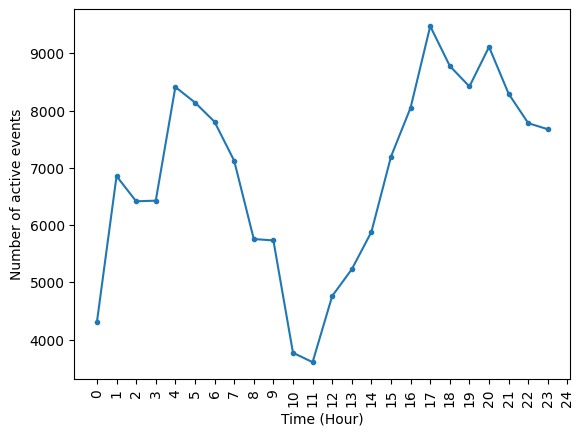

In [ ]:
t=np.arange(0, 24*3600+1, 3600)
n_edge_active=[tempo.num_active_edges( t[i], t[i+1]) for i in range(len(t)-1)]

fig,ax=plt.subplots(nrows=1, ncols=1)
ax.plot(t[:-1], n_edge_active, marker='.')

ax.set_xticks(t)
ax.set_xticklabels([i//3600 for i in t ], rotation=90)
ax.set_xlabel('Time (Hour)')
ax.set_ylabel('Number of active events')

The activity of events and nodes depends on the time of the day. Now we want to compute the forward transition matrices by first computing the laplacians. 

In [21]:
tempo.compute_laplacian_matrices()

2026-06-15 11:53:27,825 - INFO - tempnet\temporal_network.py:1267 - PID:30928 - Computing Laplacians
2026-06-15 11:53:27,845 - INFO - tempnet\temporal_network.py:1326 - PID:30928 - 0 over 1977
2026-06-15 11:53:27,847 - INFO - tempnet\temporal_network.py:1330 - PID:30928 - 0.00s
2026-06-15 11:53:28,980 - INFO - tempnet\temporal_network.py:1326 - PID:30928 - 1000 over 1977
2026-06-15 11:53:28,980 - INFO - tempnet\temporal_network.py:1330 - PID:30928 - 1.14s
2026-06-15 11:53:30,481 - INFO - tempnet\temporal_network.py:1377 - PID:30928 - Finished in 2.6372854709625244


We then proceed to computing the forward transition matrix for 3 time scales.

In [28]:
scales=[1e-8, 1e-3, 100]
for i, s in tqdm(enumerate(scales)):
    tempo.compute_inter_transition_matrices(lamda=s)

forward_transition_matrices=[reduce(lambda a, b: a @ b, tempo.inter_T[s]) for s  in scales ]

3it [00:47, 15.70s/it]


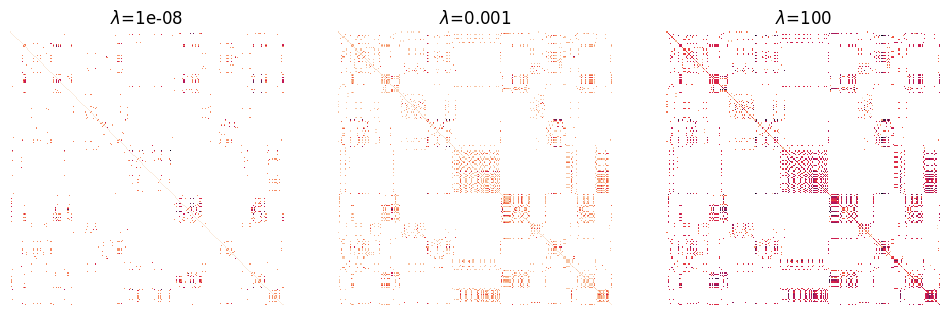

In [ ]:
fig, ax=plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

for i, (lamda, matrix) in enumerate(zip(scales, forward_transition_matrices) ):
    sns.heatmap(matrix.toarray(), ax=ax[i], square=True, cbar=False, vmin=0 , vmax=1, norm=LogNorm()
                )
    ax[i].set_title(rf'$\lambda$={lamda}')
    ax[i].set_xticks([])
    ax[i].set_yticks([])

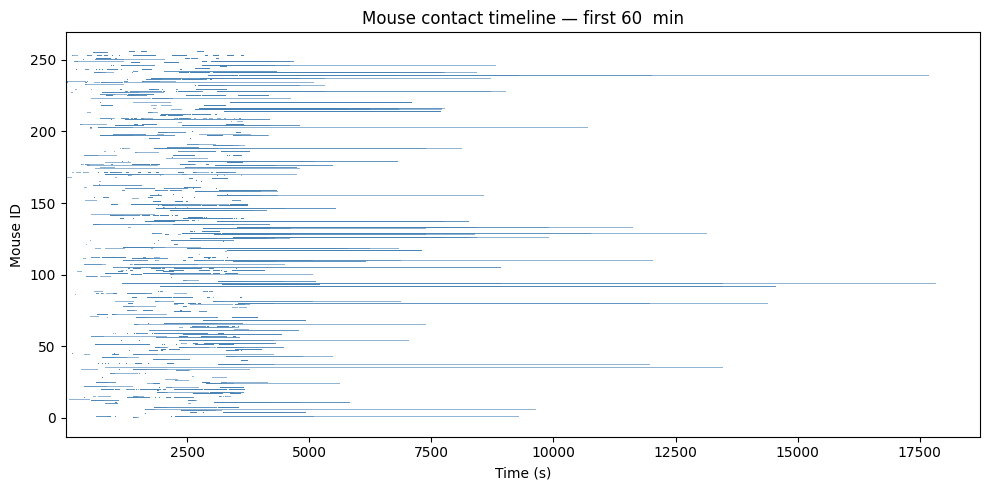

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

et = tempo.events_table
for _, row in et.iterrows():
    tgt = row[tempo._TARGETS]
    t0 = row[tempo._STARTS]
    t1 = row[tempo._ENDINGS]
    ax.barh(tgt, t1 - t0, left=t0, height=0.6, color='steelblue', alpha=0.6)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Mouse ID')
ax.set_title(f'Mouse contact timeline — first 60  min')
plt.tight_layout()
plt.show()
